# Objective:
To give metadata and information about each record, and graph the first figure of the assignment showing all raw data.

In [11]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
import os

In [12]:
# Find repository root by looking for the repository folder name
def find_repo_root(repo_name='Circular-task-assignement-Savona-Singer-Virolan'):
    """Walk up directory tree until we find the repository folder"""
    current = os.getcwd()
    while current != os.path.dirname(current):  # Stop at filesystem root
        if os.path.basename(current) == repo_name:
            return current
        current = os.path.dirname(current)
    return os.getcwd()  # Fallback to current directory


def load_data(fNamerecord, fNameresults):
    """Load recording data, markers, and results from CSV files"""
    # Load recording data
    record = np.genfromtxt(fNamerecord, delimiter=',', skip_header=3, skip_footer=0, names=True, encoding='utf-8')
    record_info = np.genfromtxt(fNamerecord, delimiter=';', skip_footer=len(record)+2, names=True, encoding='utf-8')
    
    # Load markers and results data
    markers = np.genfromtxt(fNameresults, dtype=(str,float,'U100'), delimiter=',', skip_header=3, skip_footer=9, usecols=(1,2), encoding='utf-8')
    results = np.genfromtxt(fNameresults, dtype=str, delimiter=',', skip_header=len(markers)+3, skip_footer=0, encoding='utf-8')
    
    return record, record_info, markers, results


def display_metadata(fNamerecord, fNameresults, record_info, markers, results):
    """Display header information, markers, and results table"""
    # Show recording information
    print(f"Header line information in '{fNamerecord}':\n{chr(10).join([name.replace('_', ': ') for name in record_info.dtype.names])}")
    
    # Display markers and performance information
    formatted_markers = [f"{marker[0]}: {marker[1]}" for marker in markers]
    print(f"\nMarkers in '{fNameresults}':\n{chr(10).join(formatted_markers)}")
    for row in results:
        print(' '.join(row))


def find_record_pause_markers(markers):
    """Find indices of markers containing DoRecord or DoPause"""
    record_pause_indices = []
    for i, marker in enumerate(markers):
        marker_text = str(marker[1])
        if 'DoRecord' in marker_text or 'DoPause' in marker_text:
            record_pause_indices.append(i)
    return record_pause_indices


def calculate_durations(markers, record_pause_indices):
    """Calculate durations between consecutive DoRecord/DoPause markers"""
    durations = []
    for i in range(len(record_pause_indices) - 1):
        idx_current = record_pause_indices[i]
        idx_next = record_pause_indices[i + 1]
        duration = (markers[idx_next][0] - markers[idx_current][0]) / 1000  # Convert to seconds
        durations.append(duration)
    return np.array(durations)


def display_record_times_absolute(markers, record_pause_indices, durations):
    """Display record times in absolute timestamps (Unix epoch)"""
    print("\nrecord times (milliseconds since the Unix epoch, 00:00:00 UTC on January 1, 1970):")
    for i in range(0, len(durations), 2):  # Step by 2 to get only records
        idx_start = record_pause_indices[i]
        idx_end = record_pause_indices[i + 1]
        marker_start = markers[idx_start][0]
        marker_end = markers[idx_end][0]
        duration_s = durations[i]
        print(f"{marker_start:.0f} to {marker_end:.0f} ({duration_s:.3f} s)")


def display_record_times_relative(record, markers, record_pause_indices, durations):
    """Display record times relative to first DoRecord marker"""
    first_dorecord = record[0][0] / 1000  # Convert first recorded value timestamp to seconds
    marker_start_rels = []
    marker_end_rels = []
    
    print("\nrecord times (seconds since the first DoRecord marker):")
    
    for i in range(0, len(durations), 2):  # Step by 2 to get only records
        idx_start = record_pause_indices[i]
        idx_end = record_pause_indices[i + 1]
        marker_start_rel = (markers[idx_start][0] / 1000) - first_dorecord
        marker_end_rel = (markers[idx_end][0] / 1000) - first_dorecord
        duration_s = marker_end_rel - marker_start_rel
        print(f"{marker_start_rel:7.3f} to {marker_end_rel:7.3f} ({duration_s:.3f} s)")
        marker_start_rels.append(marker_start_rel)
        marker_end_rels.append(marker_end_rel)
    
    return marker_start_rels, marker_end_rels


# ===== MAIN EXECUTION =====

# Change to repository root
repo_root = find_repo_root()
os.chdir(repo_root)

# Define file paths
fNamerecord = 'data/001MoDe_R1.csv'
fNameresults = 'data/001MoDe_R1.marker.csv'

# Load all data
record, record_info, markers, results = load_data(fNamerecord, fNameresults)

# Display metadata
display_metadata(fNamerecord, fNameresults, record_info, markers, results)

# Find DoRecord/DoPause markers
record_pause_indices = find_record_pause_markers(markers)

# Calculate durations
durations = calculate_durations(markers, record_pause_indices)

# Display absolute times
display_record_times_absolute(markers, record_pause_indices, durations)

# Display relative times and get marker boundaries
marker_start_rels, marker_end_rels = display_record_times_relative(record, markers, record_pause_indices, durations)


Header line information in 'data/001MoDe_R1.csv':
screenWidth: 1104
screenHeight: 661
cornerX: 302
cornerY: 80
centerX: 552
centerY: 330
externalRadius: 250
internalRadius: 170
borderRadius: 1
cursorRadius: 16
indexOfDifficulty: 2800696429476858
taskRadius: 2095
taskTolerance: 47
borderColor: javaawtColorr255g255b255
backgroundColor: javaawtColorr0g0b0
cursorColorRecord: javaawtColorr255g0b0
cursorColorWait: javaawtColorr255g255b0
autoStart: 3600
cycleMaxNumber: 6
cycleDuration: 20
software: LSLmouse
version: 120rc5
task: CircularTarget
isWithLSL: false

Markers in 'data/001MoDe_R1.marker.csv':
1616776712325.0: KeyTyped=32 DoCycleChange
1616776712331.0: DoCycleChange:DoStartCycleTimedSequence
1616776712333.0: DoCycleChange:DoRecord RecordDone=0 PauseDone=0 ToDo=6
1616776732336.0: DoCycleChange:DoPause RecordDone=1 PauseDone=0 ToDo=6
1616776752340.0: DoCycleChange:DoRecord RecordDone=1 PauseDone=1 ToDo=6
1616776772351.0: DoCycleChange:DoPause RecordDone=2 PauseDone=1 ToDo=6
161677679237

In [13]:
def extract_center_coordinates(fNamerecord):
    """Extract center coordinates from header line"""
    with open(fNamerecord, 'r', encoding='utf-8') as f:
        header_line = f.readline().strip()
    
    # Parse header to find centerX and centerY
    center_x = None
    center_y = None
    for part in header_line.split(';'):
        if part.startswith('centerX'):
            center_x = float(part.split()[1])
        elif part.startswith('centerY'):
            center_y = float(part.split()[1])
    
    return np.array([center_x, center_y])


def find_threshold_indices(record):
    """Find thresholds between records (characterized by timestamp == 0)"""
    return np.array([0] + list(np.where(record['timestamp'] == 0)[0]))


def extract_segments(record, threshold_indices, center):
    """Extract time, x, and y segments for each record"""
    time_segments = []
    x_segments = []
    y_segments = []
    
    for i in range(len(threshold_indices)-1):
        start_idx = threshold_indices[i] + 1  # +1 to skip the threshold line
        end_idx = threshold_indices[i+1]      # Slicing is exclusive at the end
        
        time_segment = (record['timestamp'][start_idx:end_idx] - record['timestamp'][0])/1000  # in seconds
        x_segment = record['mouseX'][start_idx:end_idx] - center[0]
        y_segment = record['mouseY'][start_idx:end_idx] - center[1]
        
        time_segments.append(time_segment)
        x_segments.append(x_segment)
        y_segments.append(y_segment)
    
    # Concatenate all segments
    time = np.concatenate(time_segments)
    x = np.concatenate(x_segments)
    y = np.concatenate(y_segments)
    
    return time, x, y


# ===== MAIN EXECUTION =====

# Extract center coordinates
center = extract_center_coordinates(fNamerecord)

# Find thresholds between records
threshold_indices = find_threshold_indices(record)

# Extract time and position data
time, x, y = extract_segments(record, threshold_indices, center)

# Get marker boundaries for plotting
starts = marker_start_rels
ends = marker_end_rels


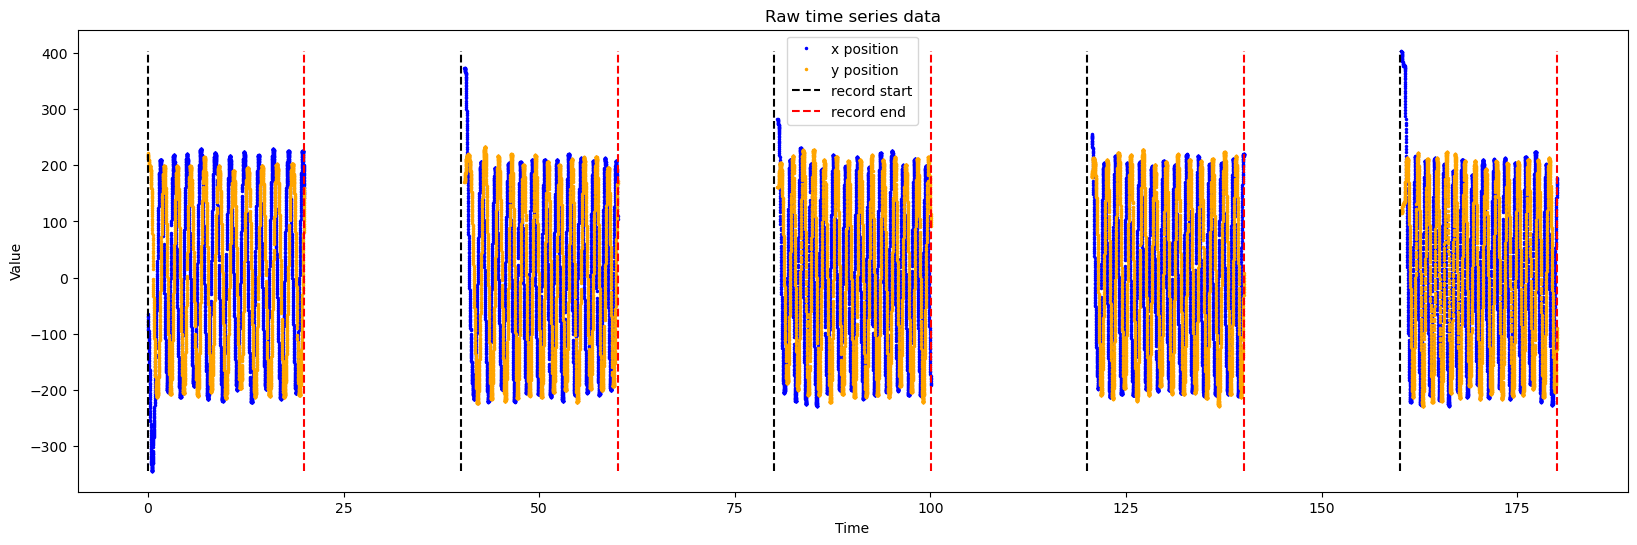

In [14]:
def plot_raw_data(time, x, y, starts, ends):
    """Plot raw time series data with record boundaries"""
    # Filter data to only include points within record boundaries
    mask = np.zeros(len(time), dtype=bool)
    for start, end in zip(starts, ends):
        mask |= (time >= start) & (time <= end)
    
    time_filtered = time[mask]
    x_filtered = x[mask]
    y_filtered = y[mask]
    
    # Determine height of vertical lines
    ymin_val = min(min(x_filtered), min(y_filtered))
    ymax_val = max(max(x_filtered), max(y_filtered))
    
    # Create plot
    plt.figure(figsize=(20, 6))
    plt.plot(time_filtered, x_filtered, label='x position', color='blue', linestyle='None', marker='o', markersize=1.5)
    plt.plot(time_filtered, y_filtered, label='y position', color='orange', linestyle='None', marker='o', markersize=1.5)
    plt.vlines(starts, ymin=ymin_val, ymax=ymax_val, colors='black', linestyles='dashed', label='record start')
    plt.vlines(ends, ymin=ymin_val, ymax=ymax_val, colors='red', linestyles='dashed', label='record end')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Raw time series data')
    plt.legend(loc = 'upper center')
    plt.show()


# ===== MAIN EXECUTION =====

# Plot the data
plot_raw_data(time, x, y, starts, ends)
